In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import diffrax
from jaxtyping import Float

import dismech_jax as djx

from util_multiset import TripletModel, validate_model, train_model, get_base_rod
from animate import animate

jax.config.update("jax_enable_x64", True)


In [2]:
class MLP(eqx.Module):
    layer1: eqx.nn.Linear
    layer2: eqx.nn.Linear

    def __init__(self, in_features: int, hidden_size: int, out_features: int, key: jax.Array):
        key1, key2 = jax.random.split(key)
        self.layer1 = eqx.nn.Linear(in_features, hidden_size, key=key1)
        self.layer2 = eqx.nn.Linear(hidden_size, out_features, key=key2)

        # small initialization
        self.layer1 = eqx.tree_at(
            lambda l: l.weight, self.layer1, self.layer1.weight * 1e-2
        )
        self.layer2 = eqx.tree_at(
            lambda l: l.weight, self.layer2, self.layer2.weight * 1e-2
        )

    def __call__(self, x: jax.Array) -> jax.Array:
        # x should have shape (5,)
        x = jax.nn.softplus(self.layer1(x))
        x = self.layer2(x)
        return jax.nn.softplus(x)   # shape (2,), always positive


class Example(TripletModel):
    K: jax.Array
    mlp: MLP

    def __init__(self, der_K: jax.Array, key: jax.Array):
        self.K = der_K
        self.mlp = MLP(in_features=5, hidden_size=10, out_features=2, key=key)

    def get_K(self, del_strain: Float[jax.Array, "5"]) -> Float[jax.Array, "2"]:
        del_strain = jnp.ravel(del_strain)

        K_base = jax.nn.softplus(self.K)   # positive base
        # K_base = self.K   # positive base, but not enforced to be positive --- IGNORE ---
        dK = self.mlp(del_strain)          # positive correction
        # return K_base*(1 + dK)                 # total positive K
        return dK + K_base                 # total positive K, with a skip connection --- IGNORE ---

    def __call__(self, del_strain: Float[jax.Array, "5"]) -> Float[jax.Array, ""]:
        K = self.get_K(del_strain)

        stretching_energy = 0.5 * (
            K[0] * del_strain[0]**2 +
            K[0] * del_strain[1]**2
        )
        bending_energy = 0.5 * (
            K[1] * del_strain[3]**2
        )

        return stretching_energy + bending_energy



In [3]:
from util import TestCase

train_file = "data/combined_output_train.npz"
valid_file = "data/combined_output_valid.npz"

# validate_model(Example)

final_model, init_K, train_history, valid_history = train_model(Example, key=jax.random.PRNGKey(42), train_file=train_file, valid_file=valid_file, n_epochs=5000, lr=5e-2, init_K=jnp.array([2.0, 0.02]) )
# final_model, train_history, valid_history = train_model(Example, key=jax.random.PRNGKey(42), train_file="data/output_valid.npz", valid_file="data/output_valid.npz", n_epochs=100, lr=1e-2)

print( "initial K: ", init_K)
print( "learned K: ", final_model.K)

xb_c:  [0.  0.  0.  0.  0.  0.5 0.  0. ]
xb_c:  [0.  0.  0.  0.  0.  0.5 0.  0. ]


/Users/radha/GitRepos/dismech-jax/examples/slinky/util_multiset.py:50: UserWarning: data/combined_output_train.npz: expected xb_c to have shape (n_traj, n_b), got shape (2, 8). Using same xb_c for all trajectories.
  warnings.warn(
/Users/radha/GitRepos/dismech-jax/examples/slinky/util_multiset.py:50: UserWarning: data/combined_output_valid.npz: expected xb_c to have shape (n_traj, n_b), got shape (2, 8). Using same xb_c for all trajectories.
  warnings.warn(


Step 0    | LR: 5.000e-02  | Train: 1.46579e-03  | Valid: 2.22552e-03  | K: [ 1.95003128 -0.02999677]
Step 10   | LR: 5.000e-02  | Train: 2.41370e-03  | Valid: 9.86326e-04  | K: [ 1.49800318 -0.52637065]
Step 20   | LR: 5.000e-02  | Train: 1.73293e-03  | Valid: 2.49062e-04  | K: [ 0.9550467  -1.06750629]
Step 30   | LR: 5.000e-02  | Train: 5.57419e-04  | Valid: 7.13666e-05  | K: [ 0.50108412 -1.59603067]
Step 40   | LR: 4.999e-02  | Train: 4.06359e-04  | Valid: 6.52909e-05  | K: [ 0.66314548 -1.94633274]
Step 50   | LR: 4.999e-02  | Train: 2.32509e-04  | Valid: 3.90254e-05  | K: [ 1.04788009 -2.1658523 ]
Step 60   | LR: 4.998e-02  | Train: 1.48253e-04  | Valid: 3.73147e-05  | K: [ 1.38169944 -2.31664297]
Step 70   | LR: 4.998e-02  | Train: 1.13380e-04  | Valid: 4.63358e-05  | K: [ 1.61502186 -2.42614921]
Step 80   | LR: 4.997e-02  | Train: 9.82219e-05  | Valid: 5.59469e-05  | K: [ 1.76807786 -2.50831038]
Step 90   | LR: 4.996e-02  | Train: 9.09743e-05  | Valid: 6.37253e-05  | K: [ 1.86

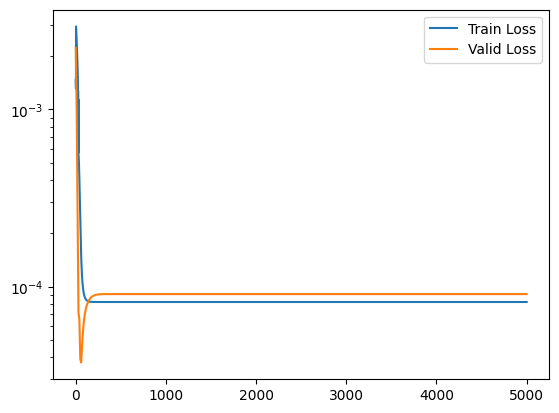

In [4]:
import matplotlib.pyplot as plt
train_np = np.asarray(train_history, dtype=float).reshape(-1)
valid_np = np.asarray(valid_history, dtype=float).reshape(-1)

idx_valid = np.where(valid_np != -1)[0]

plt.plot(np.arange(train_np.size), train_np, label="Train Loss")
plt.plot(idx_valid, valid_np[idx_valid], label="Valid Loss")
plt.yscale("log")
plt.legend()
plt.show()

### Visualizing Energy landscape

In [5]:
train = TestCase.from_npz(train_file)
valid = TestCase.from_npz(valid_file)
# train = TestCase.from_npz("output_valid.npz")
# valid = TestCase.from_npz("output_valid.npz")
print("Train:")
print("fixed idx:", train.bc.idx_b)
print("slope:", train.bc.xb_m)
print("intercept:", train.bc.xb_c)
print("Valid:")
print("fixed idx:", valid.bc.idx_b)
print("slope:", valid.bc.xb_m)
print("intercept:", valid.bc.xb_c)
lambdas = jnp.linspace(0.0, 1.0, valid.qs.shape[1])

print(valid.bc)
base, aux, _ = get_base_rod()
rods = base.with_bc(valid.bc)
print("Base rod: ", base)
print("Rods: ", rods)
pred = rods.solve(final_model, lambdas, aux, max_dlambda=5e-3, iters=5, ls_steps=10)
print(pred)
print(pred.shape)
print(valid.qs.shape)
print(train.qs.shape)
# animate(pred)

Train:
fixed idx: [ 0  1  2  3  7  8  9 10]
slope: [[[ 0.   0.   0.   0.   0.  -0.4  0.   0. ]]

 [[ 0.   0.   0.   0.   0.   1.5  0.   0. ]]]
intercept: [0.  0.  0.  0.  0.  0.5 0.  0. ]
Valid:
fixed idx: [ 0  1  2  3  7  8  9 10]
slope: [[[ 0.   0.   0.   0.   0.  -0.2  0.   0.1]]

 [[ 0.   0.   0.   0.   0.   0.5  0.  -0.1]]]
intercept: [0.  0.  0.  0.  0.  0.5 0.  0. ]
BatchedLinearBC(idx_b=i64[8](numpy), xb_m=f64[2,1,8](numpy), xb_c=f64[8](numpy))
Base rod:  Rod(
  triplets=Triplet(bar_strain=f64[1,5], l_k=f64[1,2]),
  mass=f64[11],
  q0=f64[11],
  E_ext=Gravity(F_ext=f64[11]),
  bc=AbstractBC()
)
Rods:  Rod(
  triplets=Triplet(bar_strain=f64[1,5], l_k=f64[1,2]),
  mass=f64[11],
  q0=f64[11],
  E_ext=Gravity(F_ext=f64[11]),
  bc=BatchedLinearBC(
    idx_b=i64[8](numpy), xb_m=f64[2,1,8](numpy), xb_c=f64[8](numpy)
  )
)
[[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
    2.50000000e-01 -2.83946086e-09 -1.81262860e-01  0.00000000e+00
    5.00000000e-01  0.00000000e

In [6]:
# animate(pred)

In [7]:
# animate(valid.qs)

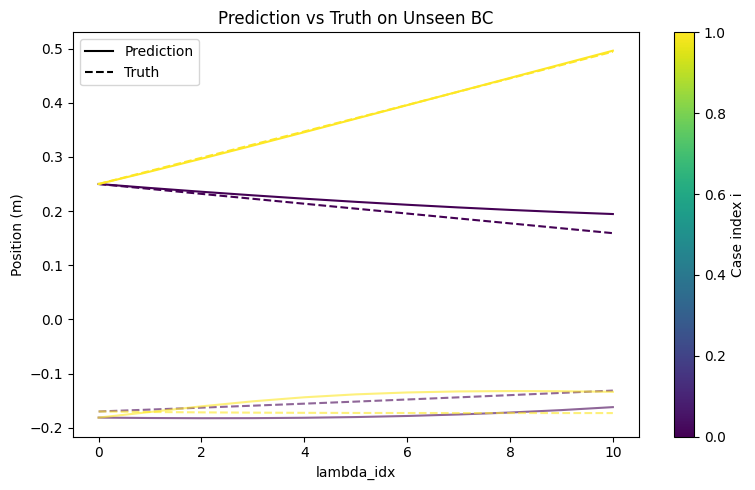

In [8]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.lines as mlines
import jax.numpy as jnp

n_cases = pred.shape[0]
colors = cm.viridis(jnp.linspace(0, 1, n_cases))

fig, ax = plt.subplots(figsize=(8, 5))

for i in range(n_cases):
    c = colors[i]

    # X
    ax.plot(pred[i, :, 4], color=c, linestyle='-')
    ax.plot(valid.qs[i, :, 4], color=c, linestyle='--')

    # Z
    ax.plot(pred[i, :, 6], color=c, linestyle='-', alpha=0.6)
    ax.plot(valid.qs[i, :, 6], color=c, linestyle='--', alpha=0.6)

pred_line = mlines.Line2D([], [], color='black', linestyle='-', label='Prediction')
truth_line = mlines.Line2D([], [], color='black', linestyle='--', label='Truth')
ax.legend(handles=[pred_line, truth_line])

sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0, vmax=n_cases - 1))
sm.set_array([])  # helps matplotlib know this is a valid mappable
fig.colorbar(sm, ax=ax, label='Case index i')

ax.set_title("Prediction vs Truth on Unseen BC")
ax.set_xlabel("lambda_idx")
ax.set_ylabel("Position (m)")
fig.tight_layout()
plt.show()

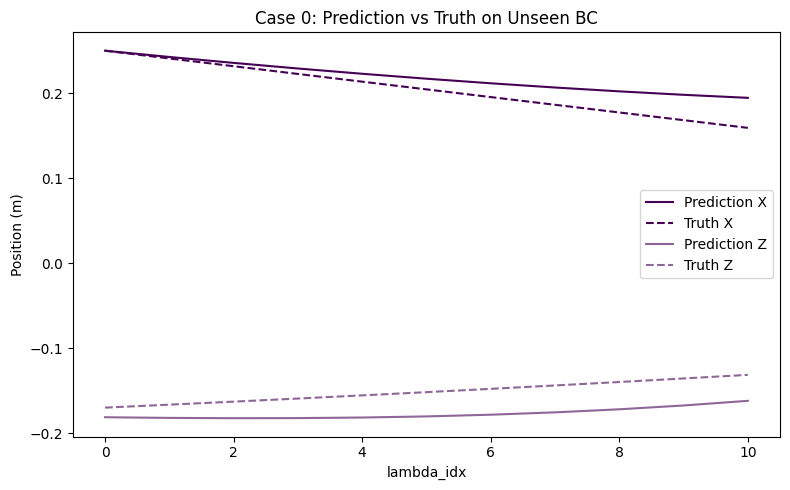

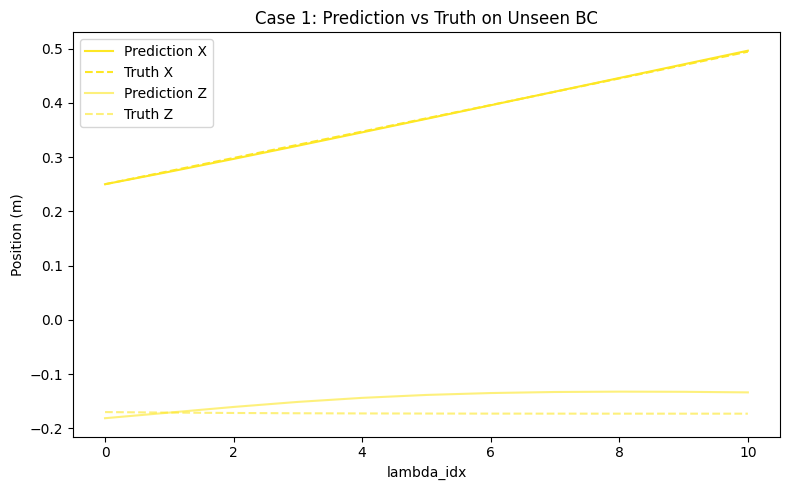

In [9]:
# create separate plots for all 5 cases for X and Z, with predicted and true on the same plot, and color by case index
for i in range(n_cases):
    c = colors[i]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(pred[i, :, 4], color=c, linestyle='-', label='Prediction X')
    ax.plot(valid.qs[i, :, 4], color=c, linestyle='--', label='Truth X')
    ax.plot(pred[i, :, 6], color=c, linestyle='-', alpha=0.6, label='Prediction Z')
    ax.plot(valid.qs[i, :, 6], color=c, linestyle='--', alpha=0.6, label='Truth Z')

    ax.set_title(f"Case {i}: Prediction vs Truth on Unseen BC")
    ax.set_xlabel("lambda_idx")
    ax.set_ylabel("Position (m)")
    ax.legend()
    fig.tight_layout()
    plt.show()

In [10]:
print("Training BC:")
print("init: ", train.qs[0, 8:11])
print("final: ", train.qs[-1, 8:11])

print("Validation BC:")
print("init: ", valid.qs[0, 8:11])
print("final: ", valid.qs[-1, 8:11])

Training BC:
init:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   9.00157272e-02  6.23413092e-06 -1.87967656e-01  0.00000000e+00
   1.80000000e-01  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   7.00164065e-02  5.87594802e-06 -1.89122811e-01  0.00000000e+00
   1.40000000e-01  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   5.00171415e-02  5.53160840e-06 -1.90022059e-01  0.00000000e+00
   1.00000000e-01  0.00000000e+00  0.00000000e+00]]
final:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   8.50000004e-01  3.73486080e-07 -5.47967535e-02  0.00000000e+00
   1.70000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   9.24999861e-01 -3.54024268e-07 -3.84803710e-02  0.00000000e+00
   1.85000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.000

In [11]:
print("initial position of the middle node in the training data: ", train.qs[0, 4:7])
print("final position of the middle node in the training data: ", train.qs[-1, 4:7])

initial position of the middle node in the training data:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.70012905e-01  7.72776659e-06 -1.80809173e-01  0.00000000e+00
   3.40000000e-01  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.50013600e-01  7.33135081e-06 -1.82970911e-01  0.00000000e+00
   3.00000000e-01  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.30014331e-01  6.96380666e-06 -1.84888700e-01  0.00000000e+00
   2.60000000e-01  0.00000000e+00  0.00000000e+00]]
final position of the middle node in the training data:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   5.49999451e-01 -8.45845735e-06 -1.14145036e-01  0.00000000e+00
   1.10000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   6.24999659e-01 -6.23204214e-06 -9.96319008e-02  0.00000000e+00
   1.25000000e+00  

In [12]:
print("initial position of the middle node in the validation data: ", valid.qs[0, 4:7])
print("final position of the middle node in the validation data: ", valid.qs[-1, 4:7])

initial position of the middle node in the validation data:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.13578310e-01 -3.93045419e-05 -1.55548195e-01  0.00000000e+00
   4.20000000e-01  0.00000000e+00  4.00000000e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.04503547e-01 -5.37021584e-05 -1.51743620e-01  0.00000000e+00
   4.00000000e-01  0.00000000e+00  5.00000000e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.95437797e-01 -6.93358761e-05 -1.47852327e-01  0.00000000e+00
   3.80000000e-01  0.00000000e+00  6.00000000e-02]]
final position of the middle node in the validation data:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   3.47015258e-01  1.46491388e-05 -1.72472247e-01  0.00000000e+00
   7.00000000e-01  0.00000000e+00 -4.00000000e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   3.71425859e-01  1.85378674e-05 -1.72679838e-01  0.00000000e+00
   7.50000000e-

In [13]:
print("initial position of the middle node in the prediction: ", pred[0, 4:7])
print("final position of the middle node in the prediction: ", pred[-1, 4:7])

initial position of the middle node in the prediction:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.22867150e-01 -4.24498564e-10 -1.81594976e-01  0.00000000e+00
   4.20000000e-01  0.00000000e+00  4.00000000e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.17063448e-01 -3.44043291e-10 -1.80284691e-01  0.00000000e+00
   4.00000000e-01  0.00000000e+00  5.00000000e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.11670512e-01 -3.16668938e-10 -1.78279568e-01  0.00000000e+00
   3.80000000e-01  0.00000000e+00  6.00000000e-02]]
final position of the middle node in the prediction:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   3.45620244e-01 -3.87010273e-08 -1.43768564e-01  0.00000000e+00
   7.00000000e-01  0.00000000e+00 -4.00000000e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   3.70518595e-01 -5.89232300e-08 -1.38382267e-01  0.00000000e+00
   7.50000000e-01  0.0000